Copied and slightly modified from Javier Roulet's `cogwheel_catalog/notebooks/1_choose_event_catalogs.ipynb`

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import json
import time
import glob
import os
import requests

from cogwheel import data, posterior

import gwosc
import gwpy.table

import sys
sys.path.insert(0, '/home/abbye.williams/GWPE/code')
from parameter_estimation import get_chirp_mass, get_table_data, check_eventname

In [3]:
catalog = 'GWTC-5.0'
event_tables = gwpy.table.EventTable.fetch_open_data(catalog)
print(f"found {len(event_tables)} events in catalog {catalog}")

found 161 events in catalog GWTC-5.0


### download events from GWOSC if needed

In [4]:
outdir = os.path.join('/home/javier.roulet/cogwheel-catalog/raw_data', catalog)
os.makedirs(outdir, exist_ok=True)
for eventname in event_tables['name']:
    os.makedirs(os.path.join(outdir, eventname))
    filenames, detector_names, tgps = data.download_timeseries(eventname, outdir=os.path.join(outdir, eventname))

KeyboardInterrupt: 

In [67]:
outdir = os.path.join('/home/javier.roulet/cogwheel-catalog/raw_data', catalog)
eventname = eventname_list_subset[19]
os.makedirs(os.path.join(outdir, eventname))
filenames, detector_names, tgps = data.download_timeseries(eventname, outdir=os.path.join(outdir, eventname))

### list of events for which to make event data

In [4]:
# get a list of events for which to make event data
catalog = 'GWTC-5.0'

# look for events in this directory
base_dir = f'/home/javier.roulet/cogwheel-catalog'
catalog_dir = os.path.join(base_dir, f'raw_data/{catalog}')

event_dir_list = glob.glob(f'{catalog_dir}/GW*')
eventname_list = [
    event_dir.split('/')[-1] for event_dir in event_dir_list
]
print(f"found {len(eventname_list)} events")

found 162 events


In [10]:
# select a subset of all the events in the catalog, for which to make .npz files
event_tables1 = gwpy.table.EventTable.fetch_open_data(catalog, selection='network_matched_filter_snr > 10')
event_tables2 = gwpy.table.EventTable.fetch_open_data(catalog, selection='network_matched_filter_snr > 11')
mask = ~np.isin(event_tables1['name'], event_tables2['name'])
event_tables = event_tables1[mask]
eventname_list_subset = []
for name in eventname_list:
    if name in ''.join(event_tables['name']):
        eventname_list_subset.append(name)

In [11]:
len(event_tables)

27

In [77]:
# pick an event from the subset
eventname =  eventname_list_subset[22]
# get the corresponding event path
eventpath = os.path.join(catalog_dir, eventname)
assert os.path.exists(eventpath), f"eventpath ({eventpath}) does not exist!"
# and get the corresponding event table
idx = [eventname == x.split('-')[0] for x in event_tables['name']]
event_table = event_tables[idx]
assert len(event_table) == 1, f"{len(event_table)} events found for {eventname} in the table"

# get the chirp mass "guess" (from the published result)
try:
    mchirp_guess = get_chirp_mass(event_table)
    print(f"got chirp mass as {mchirp_guess:.2f} Msun")
except Exception as e:
    print(e + "\nevent table:")
    print(event_table)
    mchirp_guess = None

# rough guestimate of fmax
if mchirp_guess is not None:
    if mchirp_guess < 10:
        fmax_guess = 1024
    elif 10 <= mchirp_guess < 32:
        fmax_guess = 512
    elif 32 <= mchirp_guess < 60:
        fmax_guess = 256
    else:
        fmax_guess = 128
    print(f"guessing fmax = {fmax_guess} Hz")

got chirp mass as 32.96 Msun
guessing fmax = 256 Hz


found 3 files for GW240630_101703 (GWTC-5.0) in detectors HLV
Searching incoherent solution for GW240630_101703
Set intrinsic parameters, lnL = 54.14997196994301
Set time, lnL(H) = 28.523001365768742
Set sky location, lnL = 49.38801350879661
Set phase and distance, lnL = 49.38801350879661
Set mchirp_range = (np.float64(19.207482913238902), np.float64(105.6907050246168))


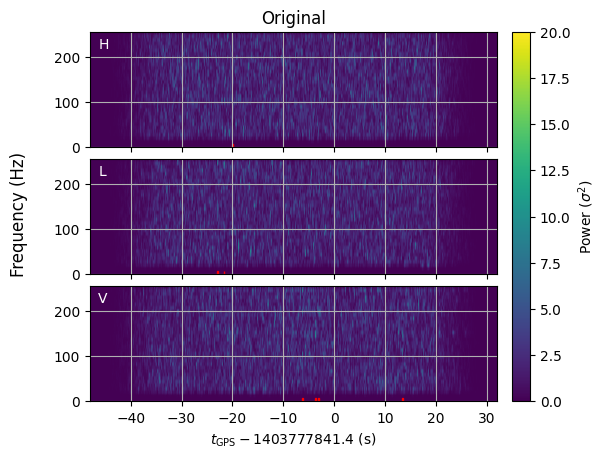

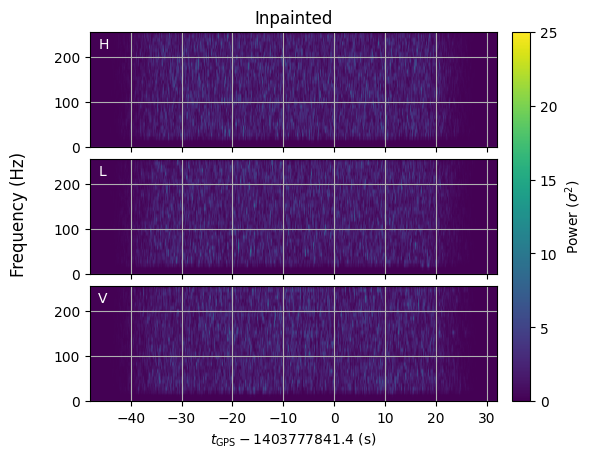

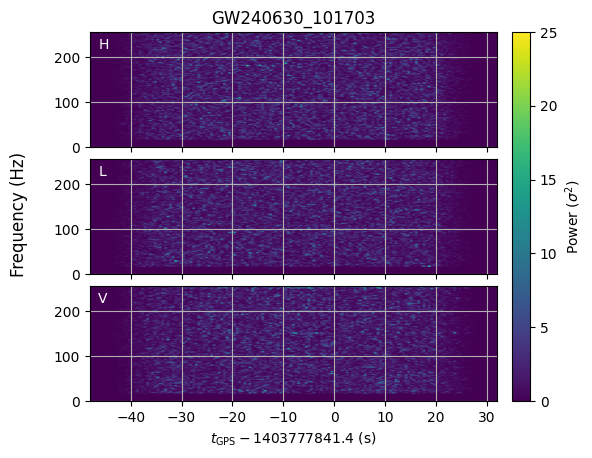

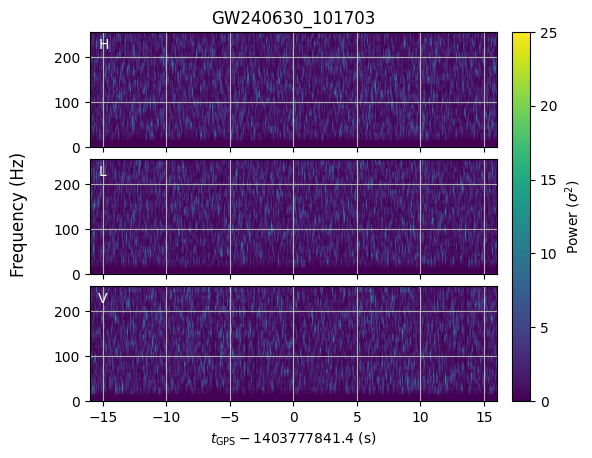

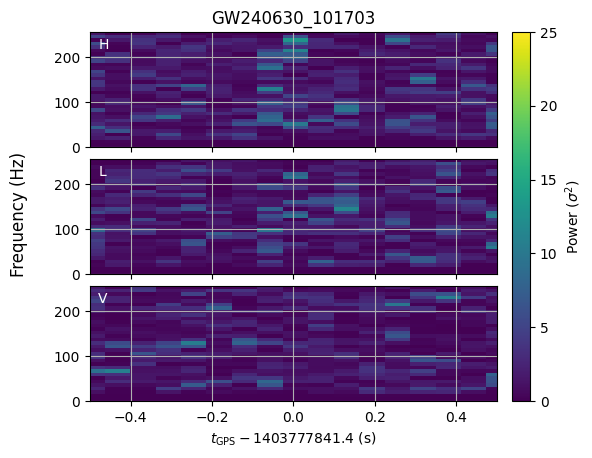

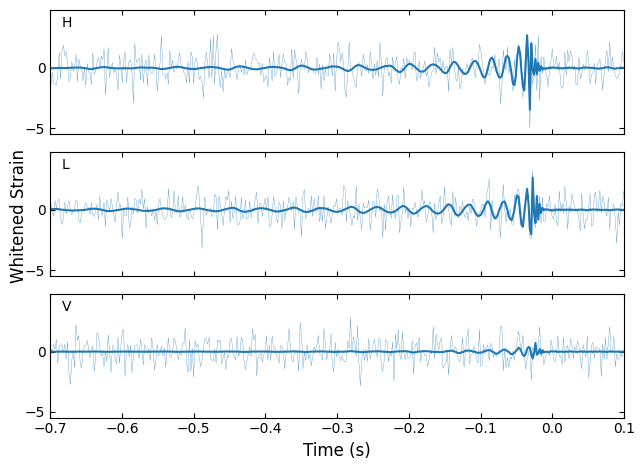

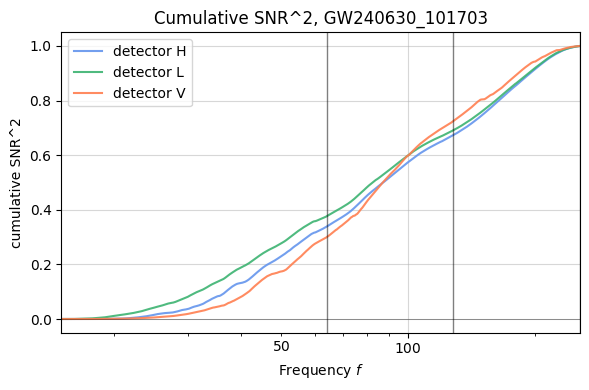

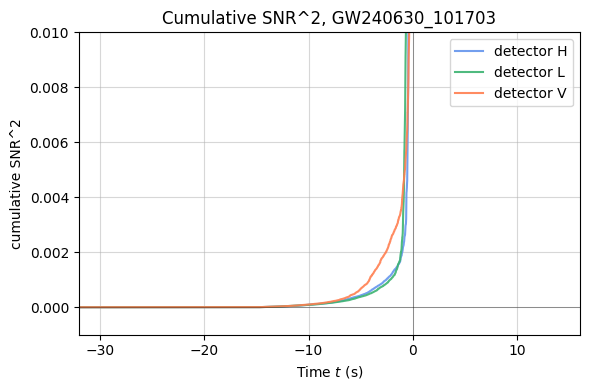

In [81]:
# kwargs for processing the event data: this is what we're testing, to save as the config if we're happy with it!
kwargs = dict(
    fmax = fmax_guess,
    wht_filter_duration = 32,
    t_before = 32,
    t_after = 16
)

filenames = sorted(Path(eventpath).glob('*.hdf5'))
assert eventname == Path(eventpath).name
detector_names = ''.join(filename.name[0] for filename in filenames)
print(f"found {len(filenames)} files for {eventname} ({catalog}) in detectors {detector_names}")
tgps = gwosc.datasets.event_gps(eventname)

event_data = data.EventData.from_timeseries(
    filenames, eventname, detector_names, tgps, **kwargs)

# suggest inpaint times
_, event_data = event_data.suggest_inpaint_times()

# check out the spectrogram
event_data.specgram(nfft=512)
event_data.specgram(np.multiply(kwargs.get('wht_filter_duration', 32), (-.5, .5)))
event_data.specgram((-.5, .5))

# compute the posterior at the max likelihood
post = posterior.Posterior.from_event(event_data, mchirp_guess, 'IMRPhenomXPHM', 'IntrinsicLVCPrior')
post.likelihood.plot_whitened_wf(post.likelihood.par_dic_0)
post.likelihood.asd_drift, post.likelihood.lnlike(post.likelihood.par_dic_0)

# cumulative SNR^2 for each detector
wht_amp = np.abs(post.likelihood._get_h_f(post.likelihood.par_dic_0)
                 * event_data.wht_filter)
cumsnr2 = np.cumsum(wht_amp**2, axis=-1)
cumsnr2 /= cumsnr2[:, [-1]]

# colorsss
cs = ['cornflowerblue', 'mediumseagreen', 'coral']

# plot
fig, ax = plt.subplots(figsize=(6,4), tight_layout=True)
for i, cumsnr2_ in enumerate(cumsnr2):
    ax.semilogx(event_data.frequencies, cumsnr2_, label=f'detector {list(detector_names)[i]}', c=cs[i], alpha=0.9)
ax.set_xlim(event_data.fbounds)
ax.set_xlabel('Frequency $f$')
ax.set_ylabel('cumulative SNR^2')
ax.axhline(0., c='k', lw=0.5, alpha=0.5)
ax.grid(alpha=0.5)
for f in [64, 128, 256, 512, 1024]:
    ax.axvline(f, c='k', alpha=0.5, lw=1)
ax.set_title(f'Cumulative SNR^2, {eventname}')
ax.legend()

# same thing but in the time domain
wht_amp_td = np.abs(np.fft.irfft(post.likelihood._get_h_f(post.likelihood.par_dic_0)
                                 * event_data.wht_filter))
cumsnr2 = np.cumsum(wht_amp_td**2, axis=-1)
cumsnr2 /= cumsnr2[:, [-1]]

# plot
fig, ax = plt.subplots(figsize=(6,4), tight_layout=True)
for i, cumsnr2_ in enumerate(cumsnr2):
    ax.plot(event_data.times - event_data.tcoarse, cumsnr2_, label=f'detector {list(detector_names)[i]}', c=cs[i], alpha=0.9)
ax.set_xlabel('Time $t$ (s)')
ax.set_ylabel('cumulative SNR^2')
ax.set_xlim(-kwargs['t_before'], kwargs['t_after'])
ax.set_ylim(-.001, 0.01)
ax.axhline(0., c='k', lw=0.5, alpha=0.5)
ax.axvline(0., c='k', lw=0.5, alpha=0.5)
ax.grid(alpha=0.5)
ax.set_title(f'Cumulative SNR^2, {eventname}')
ax.legend()

In [82]:
# once we're satisfied with the current event settings, add them to the config, then run another event
config_dir = os.path.join(base_dir, 'processed_data', catalog, eventname)
os.makedirs(config_dir, exist_ok=True)
config_fn = os.path.join(config_dir, 'event_data_kwargs.json')

with open(config_fn, 'w') as f:
    json.dump(kwargs, f, indent=4)

# and download the event data to the processed directory if it doesn't already exist
if len(glob.glob(f'{config_dir}/*.hdf5')) == 0:
    filenames, detector_names, tgps = data.download_timeseries(eventname, outdir=config_dir)